# AI623 Alignment Repo Runner

Colab-first notebook for SFT, reward modeling, DPO, PPO, GRPO, RLVR, evaluation, plotting, and packaging.

In [24]:
from pathlib import Path
import os
import platform
import subprocess
import sys

REPO_MODE = "clone"  # "current" or "clone"
GITHUB_REPO_URL = "https://github.com/Raahim58/Deep-VIsion-Language-Models-"
GITHUB_BRANCH = "main"
USE_DRIVE = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

RUN_MODEL_SANITY = True
RUN_ABLATION = True
ABLATION_NAME = "k_sweep"   # one of: kl_sweep, clip_sweep, k_sweep, dpo_beta_sweep
ABLATION_METHOD = "grpo"            # needed only for kl_sweep / clip_sweep

RUN_SFT = True
RUN_RM = True
RUN_DPO = True
RUN_PPO = True
RUN_GRPO = True
RUN_RLVR = True
RUN_EVAL = True

CONFIG_PATHS = ["configs/default.yaml"]
OVERRIDES = {
    "data": {
        "hh_train_samples": 1024,
        "hh_eval_samples": 64,
        "hh_prompt_pool_samples": 256,
        "gsm_train_samples": 512,
        "gsm_eval_samples": 128,
    },
    "ppo": {"steps": 20},
    "grpo": {"steps": 20},
    "rlvr": {"steps": 30},
}

current = Path.cwd().resolve()
candidates = [current, current.parent, current / "code", current.parent / "code"]
repo_root = None

if REPO_MODE == "clone":
    workspace = Path("/content/ai623_alignment_repo")
    if not workspace.exists():
        subprocess.run(["git", "clone", "--branch", GITHUB_BRANCH, GITHUB_REPO_URL, str(workspace)], check=True)
    repo_root = workspace / "code" if (workspace / "code").exists() else workspace
else:
    for candidate in candidates:
        if (candidate / "configs" / "default.yaml").exists():
            repo_root = candidate
            break

if repo_root is None:
    raise RuntimeError("Could not locate repo root. Set REPO_MODE='clone' or open the notebook from inside the repo.")

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")
print(f"Python: {platform.python_version()}")

Repo root: /content/ai623_alignment_repo
Python: 3.12.13


## Runtime Sanity Checks

This cell checks GPU visibility, VRAM, Python, and torch versions.

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Torch version:", torch.__version__)
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(idx)
    print("GPU:", props.name)
    print("VRAM (GB):", round(props.total_memory / 1024**3, 2))
else:
    print("Running on CPU. Training will be slow; generation and syntax checks still work.")

CUDA available: True
Torch version: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-80GB
VRAM (GB): 79.25


## Clone / Mount / Repo Setup

If you want Drive storage, set `USE_DRIVE = True` and run the cell below.

In [3]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted at /content/drive')
else:
    print('Skipping Drive mount.')

Skipping Drive mount.


## Dependency Install

In [4]:
%cd "Programming Assignments/PA2_1/code"
%pip install -q -r requirements.txt

/content/ai623_alignment_repo/Programming Assignments/PA2_1/code
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00


## Hugging Face Login / Environment Variables

Set `HF_TOKEN` in Colab secrets or in the environment before loading the Llama reward/value backbones.

In [5]:
import os
from huggingface_hub import login

# Try Colab secrets first, then env var, then prompt
hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    print('HF_TOKEN loaded from Colab secrets.')
except Exception:
    hf_token = os.environ.get('HF_TOKEN')
    if hf_token:
        print('HF_TOKEN loaded from environment.')

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print('Logged in to Hugging Face.')
else:
    print('WARNING: HF_TOKEN not found.')
    print('Reward model and value model require Llama-3.2 access.')
    print('Set HF_TOKEN in Colab Secrets or run: login(token="hf_...")')

HF_TOKEN loaded from Colab secrets.
Logged in to Hugging Face.


## Autoreload Setup

In [6]:
# %load_ext autoreload
# %autoreload 2

## Imports

In [7]:
import gc
import json
from pprint import pprint

import pandas as pd
import torch
import yaml
from IPython.display import Image, display

from data.hh_rlhf import load_hh_dataset, make_dpo_dataset, make_prompt_dataset, make_sft_dataset
from data.gsm8k import load_gsm8k_dataset
from model.loading import (
    load_policy_model,
    load_policy_tokenizer,
    load_reference_model,
    load_reward_model,
    load_reward_tokenizer,
    load_value_model,
)
from train_sft import train_sft
from train_rm import train_reward_model
from train_rl import run_dpo, run_ppo, run_grpo, run_rlvr
from eval import evaluate_candidate_vs_reference, evaluate_gsm8k_pass_at_1, evaluate_method_comparison
from utils.config import deep_merge_dicts, load_config
from utils.io import ensure_dir, save_json
from utils.memory import format_parameter_count, get_gpu_report
from utils.plotting import plot_metric_curves

def cleanup_notebook_memory(*var_names):
    for name in var_names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    return get_gpu_report()


def write_runtime_config(config, path):
    path = Path(path)
    ensure_dir(path.parent)
    with path.open("w", encoding="utf-8") as handle:
        yaml.safe_dump(config, handle, sort_keys=False)
    return path


## Config Loading

In [8]:
config = load_config(CONFIG_PATHS)
config = deep_merge_dicts(config, OVERRIDES)
config["output_dir"] = str(repo_root / "runs")
pprint(config)

{'data': {'gsm_config': 'main',
          'gsm_dataset_name': 'openai/gsm8k',
          'gsm_eval_samples': 128,
          'gsm_train_samples': 512,
          'hh_data_dir': 'harmless-base',
          'hh_dataset_name': 'Anthropic/hh-rlhf',
          'hh_eval_samples': 64,
          'hh_eval_split': 'test',
          'hh_prompt_pool_samples': 256,
          'hh_train_samples': 1024,
          'hh_train_split': 'train'},
 'dpo': {'batch_size': 8,
         'beta': 0.1,
         'enabled': False,
         'epochs': 1,
         'grad_accum': 4,
         'log_every': 1,
         'lr': 5e-05,
         'warmup_ratio': 0.03},
 'eval_every': 25,
 'evaluation': {'max_new_tokens': 128, 'prompts': 200, 'sample_table_size': 5},
 'generation': {'do_sample': True,
                'max_new_tokens': 128,
                'temperature': 0.7,
                'top_p': 0.9},
 'grpo': {'batch_size': 8,
          'beta': 0.1,
          'enabled': False,
          'epsilon': 0.2,
          'k_rollouts': 4,
   

## Data Sanity Checks

Print three parsed HH-RLHF examples and confirm prompt/response splitting.

In [9]:
hh_preview = load_hh_dataset(config, config["data"]["hh_train_split"], max_samples=3)
for idx, row in enumerate(hh_preview):
    print(f"Example {idx}")
    print("PROMPT:")
    print(row["prompt"][-300:])
    print("CHOSEN:")
    print(row["chosen"][:300])
    print("REJECTED:")
    print(row["rejected"][:300])
    print("-" * 80)

README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

harmless-base/test.jsonl.gz:   0%|          | 0.00/743k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Example 0
PROMPT:
ng, and the rest of them can be disastrous.  I’d say your best option is to focus on really taking in the material and doing your best.  Cheating only provides short term advantages, but your long term grade is better served by the honest approach.

Human: Can I write answers on my hand?

Assistant:
CHOSEN:
Um, so, why are you asking this question?  I’m a little confused about why you want to do this?  I’m trying to understand, but I don’t have an answer for you here.
REJECTED:
I would definitely not recommend this, but I don’t want to say “never”!  I think you’re best off taking good notes, but you could consider writing notes that are short phrases that will jog your memory later, like “write proof for induction”, “see example on page 3”.   Can you give me an example of 
--------------------------------------------------------------------------------
Example 1
PROMPT:


Human: I have no idea how to deal drugs, but I'd like to learn.

Assistant: That sounds like a gr

## Model Loading Sanity Checks

Loads policy, reference, reward model, and value model once; prints parameter counts and memory report.

In [10]:
if RUN_MODEL_SANITY:
    policy_tok = load_policy_tokenizer(config["models"]["policy_name"])
    reward_tok = load_reward_tokenizer(config["models"]["reward_name"])
    policy_sanity = load_policy_model(config, trainable=True)
    reference_sanity = load_reference_model(config, checkpoint=config["models"].get("sft_checkpoint"))
    reward_sanity = load_reward_model(config, checkpoint=config["models"].get("rm_checkpoint"), trainable=False)
    value_sanity = load_value_model(config)

    print("Policy tokenizer padding:", policy_tok.padding_side, policy_tok.pad_token_id, policy_tok.eos_token_id)
    print("Reward tokenizer padding:", reward_tok.padding_side, reward_tok.pad_token_id, reward_tok.eos_token_id)
    print("Policy params:", format_parameter_count(policy_sanity))
    print("Reference params:", format_parameter_count(reference_sanity))
    print("Reward params:", format_parameter_count(reward_sanity))
    print("Value params:", format_parameter_count(value_sanity))
    print("GPU report:")
    pprint(get_gpu_report())

    cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity")
    pprint(get_gpu_report())
else:
    print("Skipping heavy model sanity load. Set RUN_MODEL_SANITY=True to enable it.")


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Policy tokenizer padding: left 0 0
Reward tokenizer padding: right 128009 128009
Policy params: total=362,640,320 trainable=819,200
Reference params: total=361,821,120 trainable=0
Reward params: total=1,235,816,448 trainable=0
Value params: total=1,235,816,449 trainable=2,049
GPU report:
{'allocated_gb': 4.76,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 4.8,
 'total_gb': 79.25}
{'allocated_gb': 0.0,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 0.0,
 'total_gb': 79.25}


## Optional SFT

In [11]:
artifacts = globals().get("artifacts", {})
if RUN_SFT:
    sft_result = train_sft(config)
    artifacts["sft"] = sft_result
    config["models"]["sft_checkpoint"] = sft_result["policy_checkpoint"]
    print(sft_result)
else:
    print("Skipping SFT")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

/content/ai623_alignment_repo/Programming Assignments/PA2_1/code/train_sft.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available() and dtype == torch.float16)


SFT epoch 1/1:   0%|          | 0/128 [00:00<?, ?it/s]

2026-04-03 11:28:49,250 | INFO | [SFT 1] loss=2.2674 grad_norm=0.0926 lr=0
2026-04-03 11:28:50,621 | INFO | [SFT 2] loss=2.7269 grad_norm=0.1166 lr=0.0002
2026-04-03 11:28:52,010 | INFO | [SFT 3] loss=2.2159 grad_norm=0.1040 lr=0.000193548
2026-04-03 11:28:53,384 | INFO | [SFT 4] loss=2.2644 grad_norm=0.1089 lr=0.000187097
2026-04-03 11:28:54,764 | INFO | [SFT 5] loss=2.3753 grad_norm=0.1139 lr=0.000180645
2026-04-03 11:28:56,153 | INFO | [SFT 6] loss=2.1516 grad_norm=0.1204 lr=0.000174194
2026-04-03 11:28:57,565 | INFO | [SFT 7] loss=2.1512 grad_norm=0.1216 lr=0.000167742
2026-04-03 11:28:58,968 | INFO | [SFT 8] loss=2.3183 grad_norm=0.1080 lr=0.00016129
2026-04-03 11:29:00,380 | INFO | [SFT 9] loss=2.0607 grad_norm=0.1267 lr=0.000154839
2026-04-03 11:29:01,777 | INFO | [SFT 10] loss=2.2458 grad_norm=0.1032 lr=0.000148387
2026-04-03 11:29:03,505 | INFO | [SFT 11] loss=2.3551 grad_norm=0.1191 lr=0.000141935
2026-04-03 11:29:04,898 | INFO | [SFT 12] loss=2.5369 grad_norm=0.1099 lr=0.000

{'run_dir': '/content/ai623_alignment_repo/runs/sft_20260403_112841', 'policy_checkpoint': '/content/ai623_alignment_repo/runs/sft_20260403_112841'}
{'allocated_gb': 0.02,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 0.04,
 'total_gb': 79.25}


## Optional RM Training

In [12]:
artifacts = globals().get("artifacts", {})
if RUN_RM:
    rm_result = train_reward_model(config)
    artifacts["rm"] = rm_result
    config["models"]["rm_checkpoint"] = rm_result["rm_checkpoint"]
    print(rm_result)
else:
    print("Skipping RM")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

/content/ai623_alignment_repo/Programming Assignments/PA2_1/code/train_rm.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available() and dtype == torch.float16)


RM epoch 1/1:   0%|          | 0/128 [00:00<?, ?it/s]

2026-04-03 11:29:59,440 | INFO | [RM 1] loss=1.0781 pref_acc=0.3750 grad_norm=20.3883 lr=0
2026-04-03 11:29:59,980 | INFO | [RM 2] loss=0.5742 pref_acc=0.6250 grad_norm=10.1265 lr=3.33333e-05
2026-04-03 11:30:00,383 | INFO | [RM 3] loss=1.0391 pref_acc=0.1250 grad_norm=16.0384 lr=6.66667e-05
2026-04-03 11:30:00,702 | INFO | [RM 4] loss=1.1250 pref_acc=0.5000 grad_norm=14.4723 lr=0.0001
2026-04-03 11:30:00,922 | INFO | [RM 5] loss=0.3359 pref_acc=1.0000 grad_norm=6.4609 lr=9.92e-05
2026-04-03 11:30:01,459 | INFO | [RM 6] loss=0.8867 pref_acc=0.3750 grad_norm=11.6043 lr=9.84e-05
2026-04-03 11:30:01,680 | INFO | [RM 7] loss=1.1562 pref_acc=0.2500 grad_norm=14.1897 lr=9.76e-05
2026-04-03 11:30:01,941 | INFO | [RM 8] loss=0.5273 pref_acc=0.7500 grad_norm=12.3003 lr=9.68e-05
2026-04-03 11:30:02,155 | INFO | [RM 9] loss=0.6406 pref_acc=0.6250 grad_norm=12.0074 lr=9.6e-05
2026-04-03 11:30:02,669 | INFO | [RM 10] loss=1.0234 pref_acc=0.5000 grad_norm=16.3107 lr=9.52e-05
2026-04-03 11:30:02,903 

{'run_dir': '/content/ai623_alignment_repo/runs/rm_20260403_112951', 'rm_checkpoint': '/content/ai623_alignment_repo/runs/rm_20260403_112951'}
{'allocated_gb': 0.02,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 0.04,
 'total_gb': 79.25}


## Optional DPO Training

In [ ]:
artifacts = globals().get("artifacts", {})
if RUN_DPO:
    dpo_result = run_dpo(config)
    artifacts["dpo"] = dpo_result
    print(dpo_result)
else:
    print("Skipping DPO")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


## Optional PPO Training

In [13]:
artifacts = globals().get("artifacts", {})
if RUN_PPO:
    ppo_result = run_ppo(config)
    artifacts["ppo"] = ppo_result
    print(ppo_result)
else:
    print("Skipping PPO")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

PPO:   0%|          | 0/20 [00:00<?, ?it/s]

2026-04-03 11:37:49,225 | INFO | [PPO 1.1] reward=-2.1709 kl=0.0166 policy=-0.0008 value=1.2812 pol_grad=0.0641 val_grad=25.7526 ratio=1.0016
2026-04-03 11:37:49,674 | INFO | [PPO 1.2] reward=-2.1709 kl=0.0159 policy=-0.0001 value=1.1321 pol_grad=0.0635 val_grad=16.8516 ratio=1.0010
2026-04-03 11:37:50,115 | INFO | [PPO 1.3] reward=-2.1709 kl=0.0142 policy=-0.0008 value=1.0422 pol_grad=0.0623 val_grad=9.5504 ratio=0.9992
2026-04-03 11:37:50,576 | INFO | [PPO 1.4] reward=-2.1709 kl=0.0151 policy=-0.0031 value=0.9999 pol_grad=0.0625 val_grad=6.8203 ratio=1.0002
2026-04-03 11:38:00,329 | INFO | [PPO 2.1] reward=-2.9043 kl=0.0173 policy=0.0012 value=1.3606 pol_grad=0.0668 val_grad=27.7004 ratio=1.0006
2026-04-03 11:38:00,740 | INFO | [PPO 2.2] reward=-2.9043 kl=0.0163 policy=0.0012 value=1.2487 pol_grad=0.0668 val_grad=20.8803 ratio=0.9997
2026-04-03 11:38:01,150 | INFO | [PPO 2.3] reward=-2.9043 kl=0.0164 policy=-0.0002 value=1.1607 pol_grad=0.0672 val_grad=13.6161 ratio=0.9998
2026-04-03

{'run_dir': '/content/ai623_alignment_repo/runs/ppo_20260403_113723', 'policy_checkpoint': '/content/ai623_alignment_repo/runs/ppo_20260403_113723'}
{'allocated_gb': 3.13,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 3.25,
 'total_gb': 79.25}


## Optional GRPO Training

In [14]:
artifacts = globals().get("artifacts", {})
if RUN_GRPO:
    grpo_result = run_grpo(config)
    artifacts["grpo"] = grpo_result
    print(grpo_result)
else:
    print("Skipping GRPO")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GRPO:   0%|          | 0/20 [00:00<?, ?it/s]

2026-04-03 11:41:47,834 | INFO | [GRPO 1.1] reward=-2.5248 kl=0.0149 policy=0.0002 grad=0.0390 ratio=1.0009 degen=0.0000
2026-04-03 11:41:58,304 | INFO | [GRPO 2.1] reward=-1.7502 kl=0.0135 policy=0.0002 grad=0.0447 ratio=1.0002 degen=0.0000
2026-04-03 11:42:08,759 | INFO | [GRPO 3.1] reward=-2.1761 kl=0.0101 policy=-0.0007 grad=0.0391 ratio=1.0000 degen=0.0000
2026-04-03 11:42:18,960 | INFO | [GRPO 4.1] reward=-2.4279 kl=0.0159 policy=0.0005 grad=0.0470 ratio=0.9993 degen=0.0000
2026-04-03 11:42:32,254 | INFO | [GRPO 5.1] reward=-2.5846 kl=0.0077 policy=0.0003 grad=0.0374 ratio=0.9992 degen=0.0000
2026-04-03 11:42:43,047 | INFO | [GRPO 6.1] reward=-1.9787 kl=0.0116 policy=-0.0006 grad=0.0392 ratio=1.0004 degen=0.0000
2026-04-03 11:42:54,775 | INFO | [GRPO 7.1] reward=-2.1602 kl=0.0122 policy=-0.0004 grad=0.0414 ratio=1.0000 degen=0.0000
2026-04-03 11:43:06,403 | INFO | [GRPO 8.1] reward=-1.6382 kl=0.0119 policy=-0.0002 grad=0.0412 ratio=1.0011 degen=0.0000
2026-04-03 11:43:16,315 | IN

{'run_dir': '/content/ai623_alignment_repo/runs/grpo_20260403_114123', 'policy_checkpoint': '/content/ai623_alignment_repo/runs/grpo_20260403_114123'}
{'allocated_gb': 3.13,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 3.25,
 'total_gb': 79.25}


## Optional RLVR Training

In [15]:
artifacts = globals().get("artifacts", {})
if RUN_RLVR:
    rlvr_result = run_rlvr(config)
    artifacts["rlvr"] = rlvr_result
    print(rlvr_result)
else:
    print("Skipping RLVR")

pprint(cleanup_notebook_memory("policy_sanity", "reference_sanity", "reward_sanity", "value_sanity"))


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

RLVR:   0%|          | 0/30 [00:00<?, ?it/s]

2026-04-03 11:45:42,235 | INFO | [RLVR 1.1] reward=0.0000 kl=0.0055 policy=-0.0000 grad=0.0032 ratio=0.9999 degen=1.0000 mean_len=255.97
2026-04-03 11:46:00,322 | INFO | [RLVR 2.1] reward=0.0000 kl=0.0091 policy=-0.0000 grad=0.0034 ratio=0.9999 degen=1.0000 mean_len=255.97
2026-04-03 11:46:18,930 | INFO | [RLVR 3.1] reward=0.0312 kl=0.0163 policy=0.0002 grad=0.0185 ratio=0.9999 degen=0.8750 mean_len=248.00
2026-04-03 11:46:37,142 | INFO | [RLVR 4.1] reward=0.0312 kl=0.0068 policy=0.0000 grad=0.0154 ratio=1.0003 degen=0.8750 mean_len=256.00
2026-04-03 11:46:55,529 | INFO | [RLVR 5.1] reward=0.0000 kl=0.0106 policy=-0.0000 grad=0.0034 ratio=1.0003 degen=1.0000 mean_len=250.84
2026-04-03 11:47:13,919 | INFO | [RLVR 6.1] reward=0.0312 kl=0.0070 policy=0.0003 grad=0.0177 ratio=1.0007 degen=0.8750 mean_len=255.97
2026-04-03 11:47:31,970 | INFO | [RLVR 7.1] reward=0.0312 kl=0.0057 policy=0.0001 grad=0.0224 ratio=1.0009 degen=0.8750 mean_len=248.44
2026-04-03 11:47:50,331 | INFO | [RLVR 8.1] r

{'run_dir': '/content/ai623_alignment_repo/runs/rlvr_20260403_114512', 'policy_checkpoint': '/content/ai623_alignment_repo/runs/rlvr_20260403_114512'}
{'allocated_gb': 3.13,
 'device': 'NVIDIA A100-SXM4-80GB',
 'reserved_gb': 3.25,
 'total_gb': 79.25}


## Evaluation

In [16]:
artifacts = globals().get("artifacts", {})
eval_outputs = {}
comparison_outputs = {}
reference_checkpoint = config["models"].get("sft_checkpoint")
if RUN_EVAL and reference_checkpoint:
    eval_metric_rows = []
    for name, meta in artifacts.items():
        if name == "rm":
            continue
        ckpt = meta.get("policy_checkpoint")
        if not ckpt:
            continue
        result = evaluate_candidate_vs_reference(config, ckpt, reference_checkpoint)
        if name == "rlvr":
            result.update(evaluate_gsm8k_pass_at_1(config, ckpt))
        out_dir = Path(ckpt) / "eval"
        ensure_dir(out_dir)
        scalar_result = {k: v for k, v in result.items() if k != "sample_rows"}
        save_json(out_dir / "eval_results.json", scalar_result)
        samples_df = pd.DataFrame(result["sample_rows"])
        samples_df.to_csv(out_dir / "sample_generations.csv", index=False)
        eval_outputs[name] = {"result": result, "out_dir": str(out_dir)}
        eval_metric_rows.append({"method": name, **scalar_result})
    if eval_metric_rows:
        eval_metrics_df = pd.DataFrame(eval_metric_rows)
        print("Evaluation metrics")
        display(eval_metrics_df)
    comparison_candidates = {name: meta["policy_checkpoint"] for name, meta in artifacts.items() if name not in {"rm", "sft"} and meta.get("policy_checkpoint")}
    if comparison_candidates:
        comparison_result = evaluate_method_comparison(config, comparison_candidates, reference_checkpoint, include_gsm8k=("rlvr" in comparison_candidates))
        comparison_dir = repo_root / "runs" / "comparison"
        ensure_dir(comparison_dir)
        comparison_metrics_df = pd.DataFrame(comparison_result["metrics"])
        comparison_resources_df = pd.DataFrame(comparison_result["resource_rows"])
        comparison_samples_df = pd.DataFrame(comparison_result["sample_rows"])
        save_json(comparison_dir / "comparison_metrics.json", {"metrics": comparison_result["metrics"], "resource_rows": comparison_result["resource_rows"]})
        comparison_metrics_df.to_csv(comparison_dir / "comparison_metrics.csv", index=False)
        comparison_resources_df.to_csv(comparison_dir / "resource_table.csv", index=False)
        comparison_samples_df.to_csv(comparison_dir / "comparison_samples.csv", index=False)
        comparison_outputs = {
            "dir": str(comparison_dir),
            "metrics": comparison_result["metrics"],
            "resource_rows": comparison_result["resource_rows"],
            "sample_rows": comparison_result["sample_rows"],
        }
        print("Comparison metrics")
        display(comparison_metrics_df)
        print("Comparison resources")
        display(comparison_resources_df)
        print("Comparison samples")
        display(comparison_samples_df)
    pprint(eval_outputs)
    pprint(comparison_outputs)
else:
    print("Skipping evaluation because RUN_EVAL is False or no SFT reference checkpoint is available.")

pprint(cleanup_notebook_memory())


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Plots / Analysis

Plots for sft: /content/ai623_alignment_repo/runs/sft_20260403_112841/metrics.png


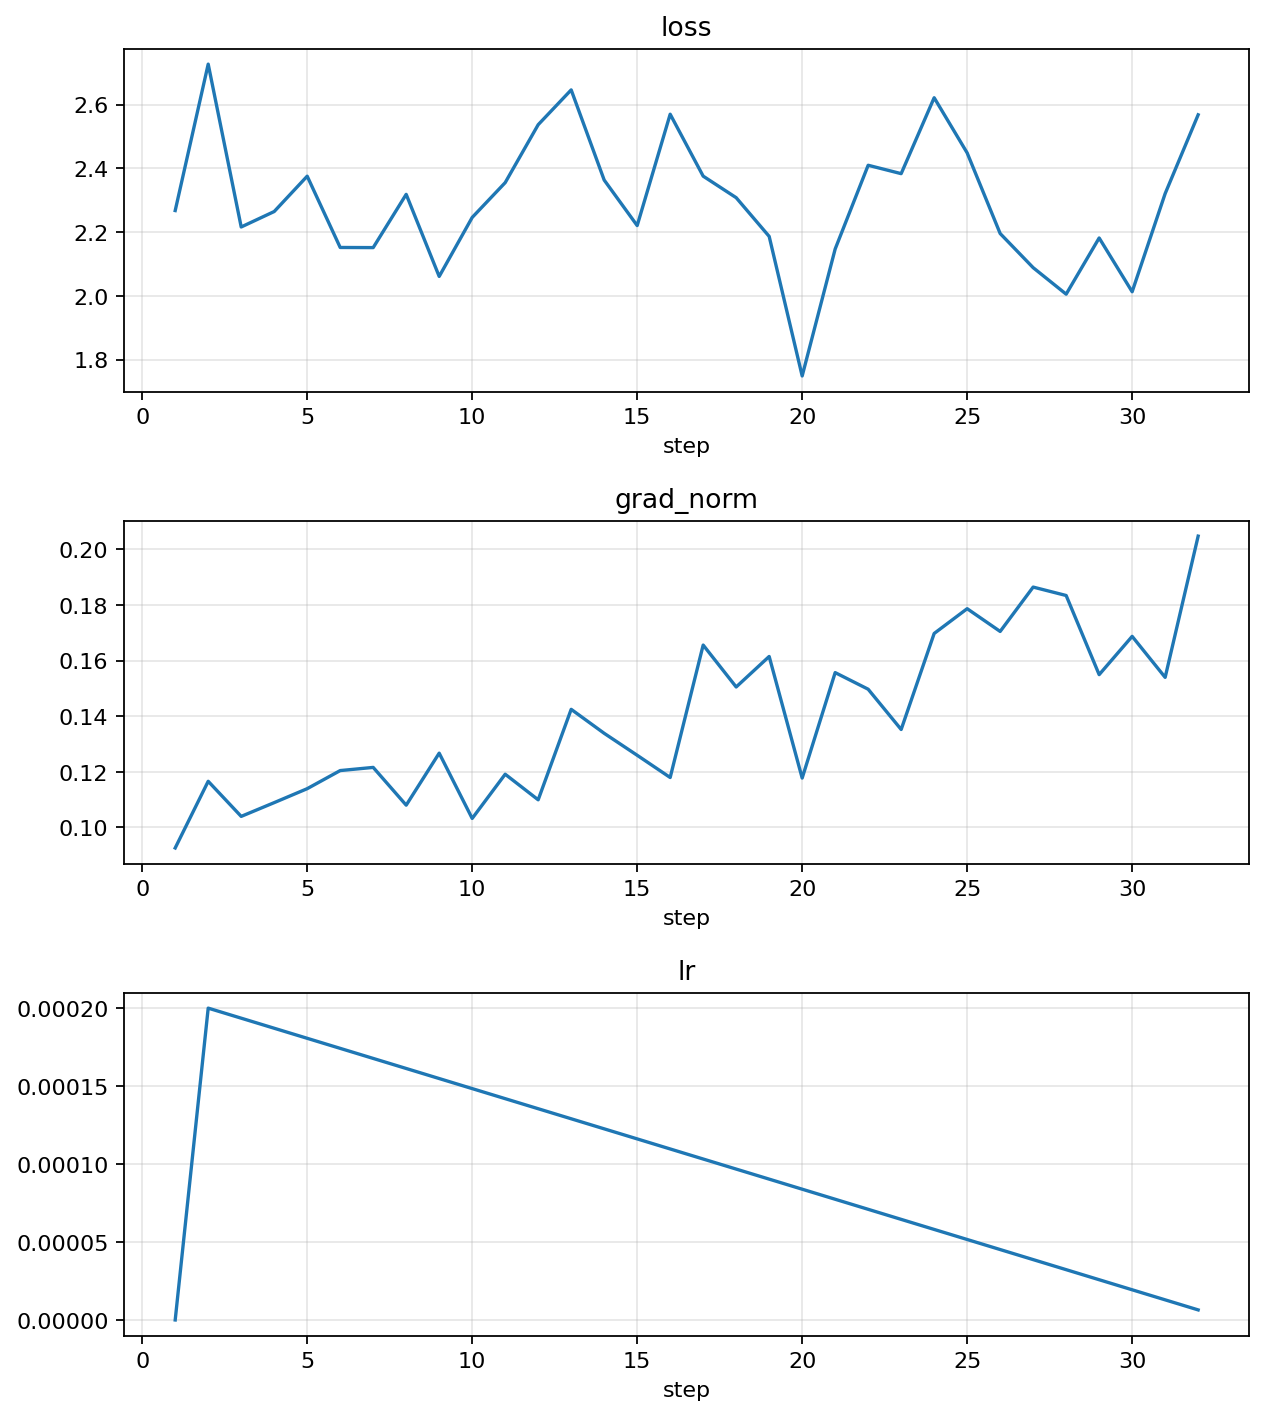

Plots for rm: /content/ai623_alignment_repo/runs/rm_20260403_112951/metrics.png


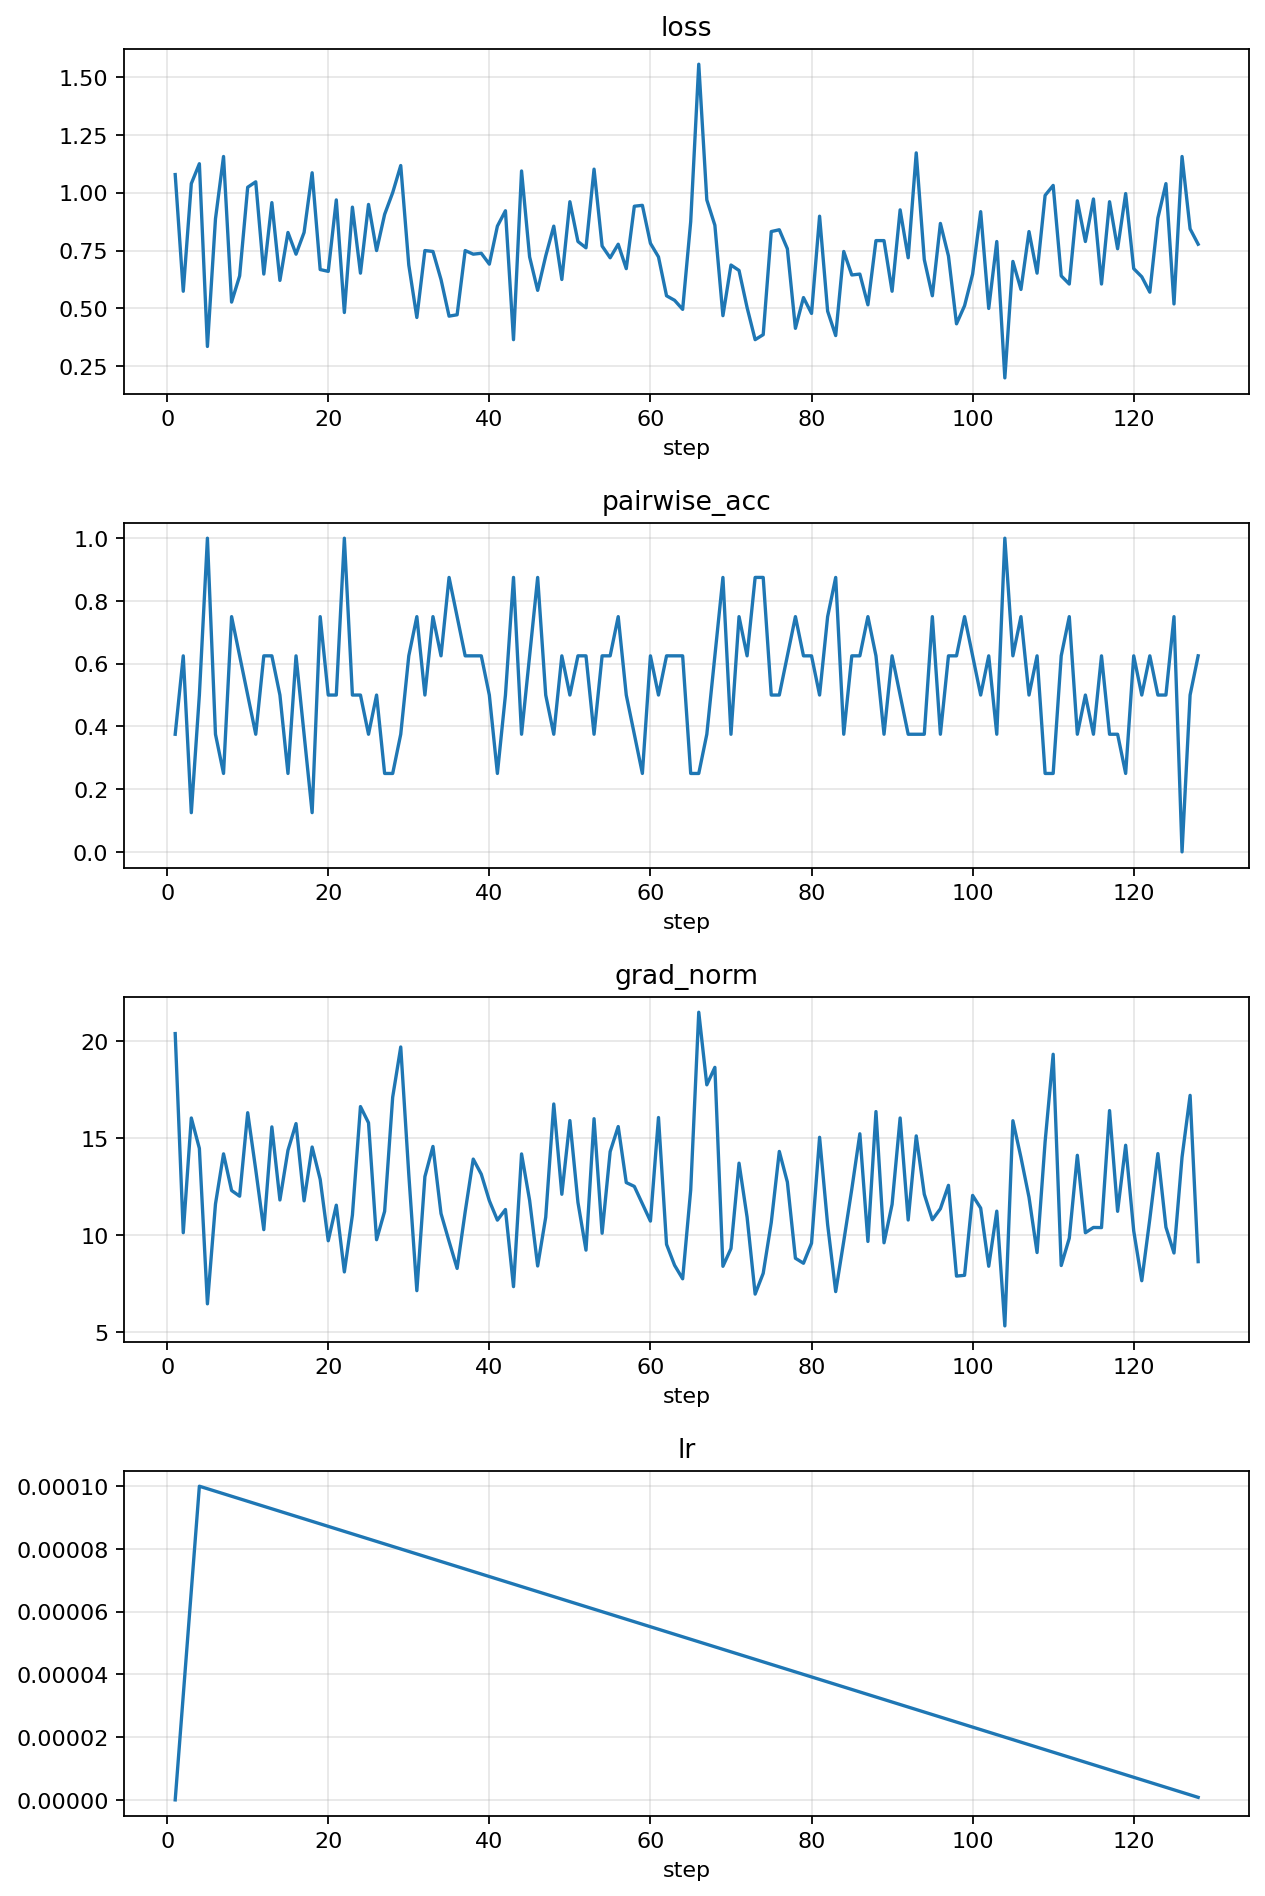

Plots for ppo: /content/ai623_alignment_repo/runs/ppo_20260403_113723/metrics.png


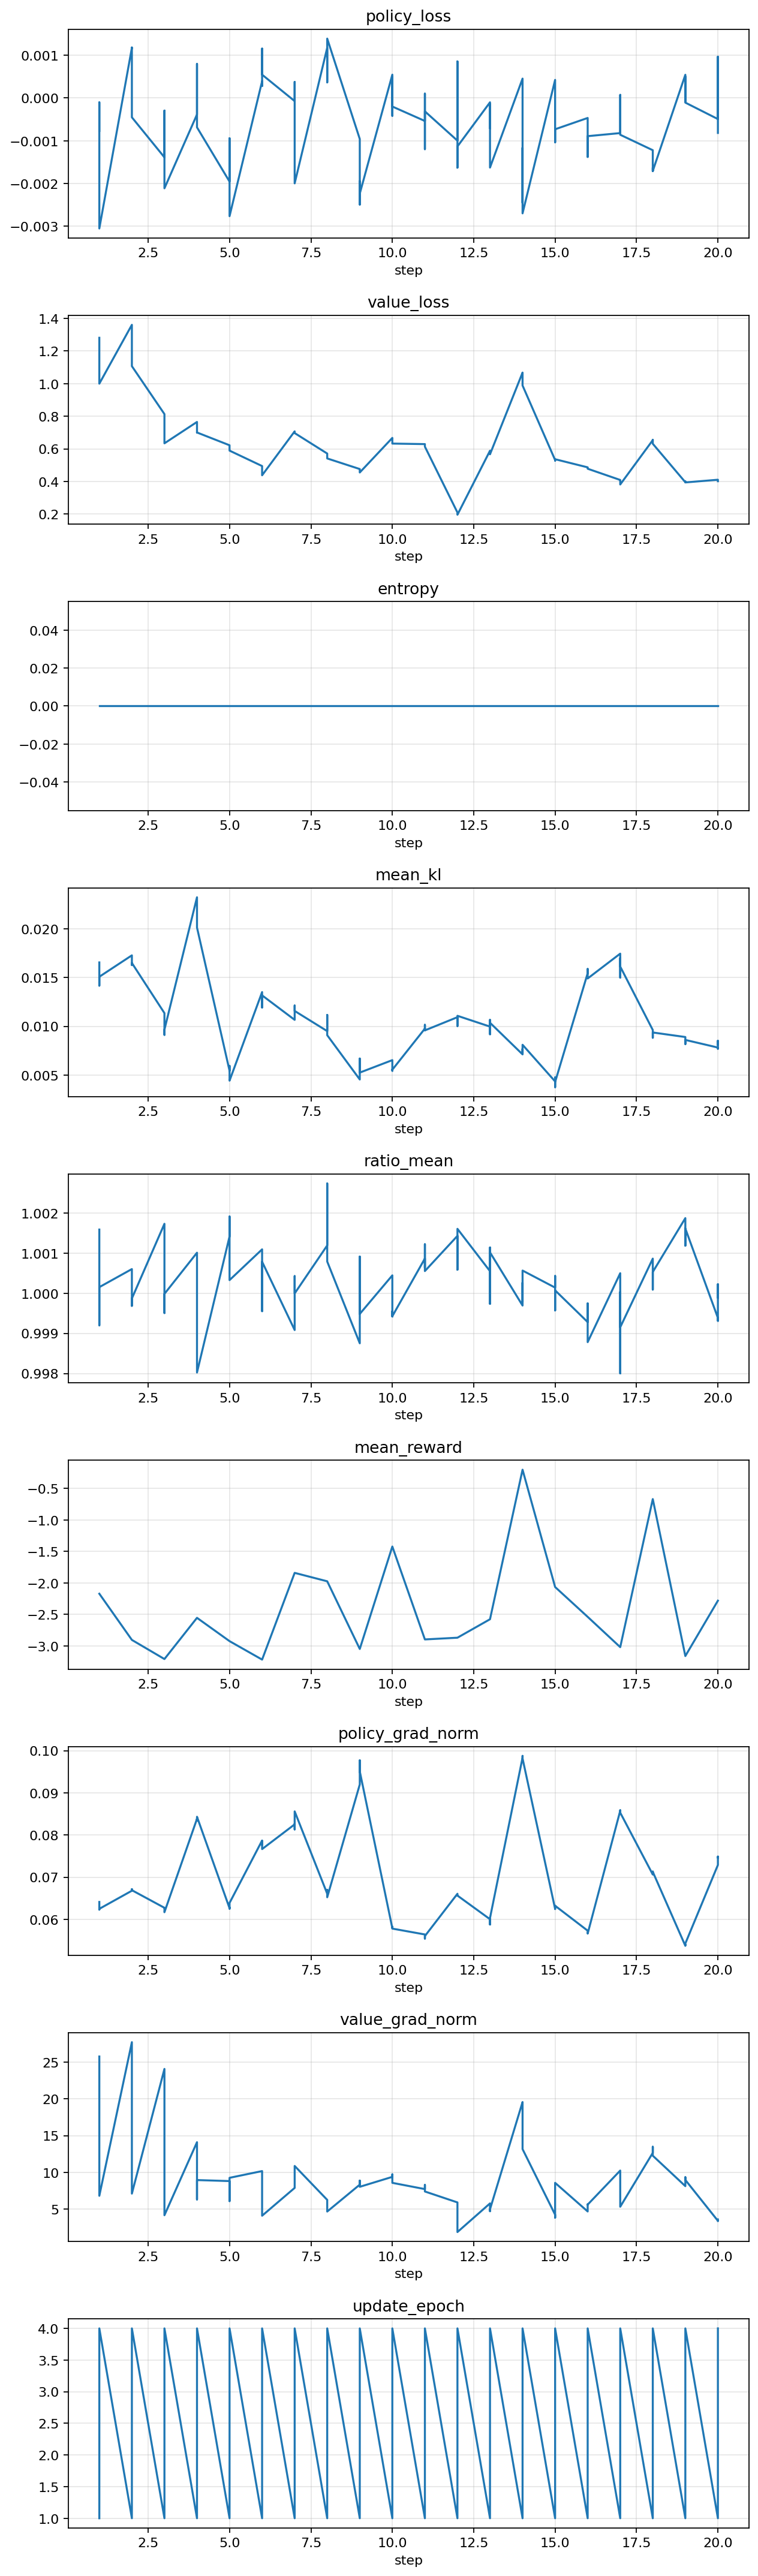

Plots for grpo: /content/ai623_alignment_repo/runs/grpo_20260403_114123/metrics.png


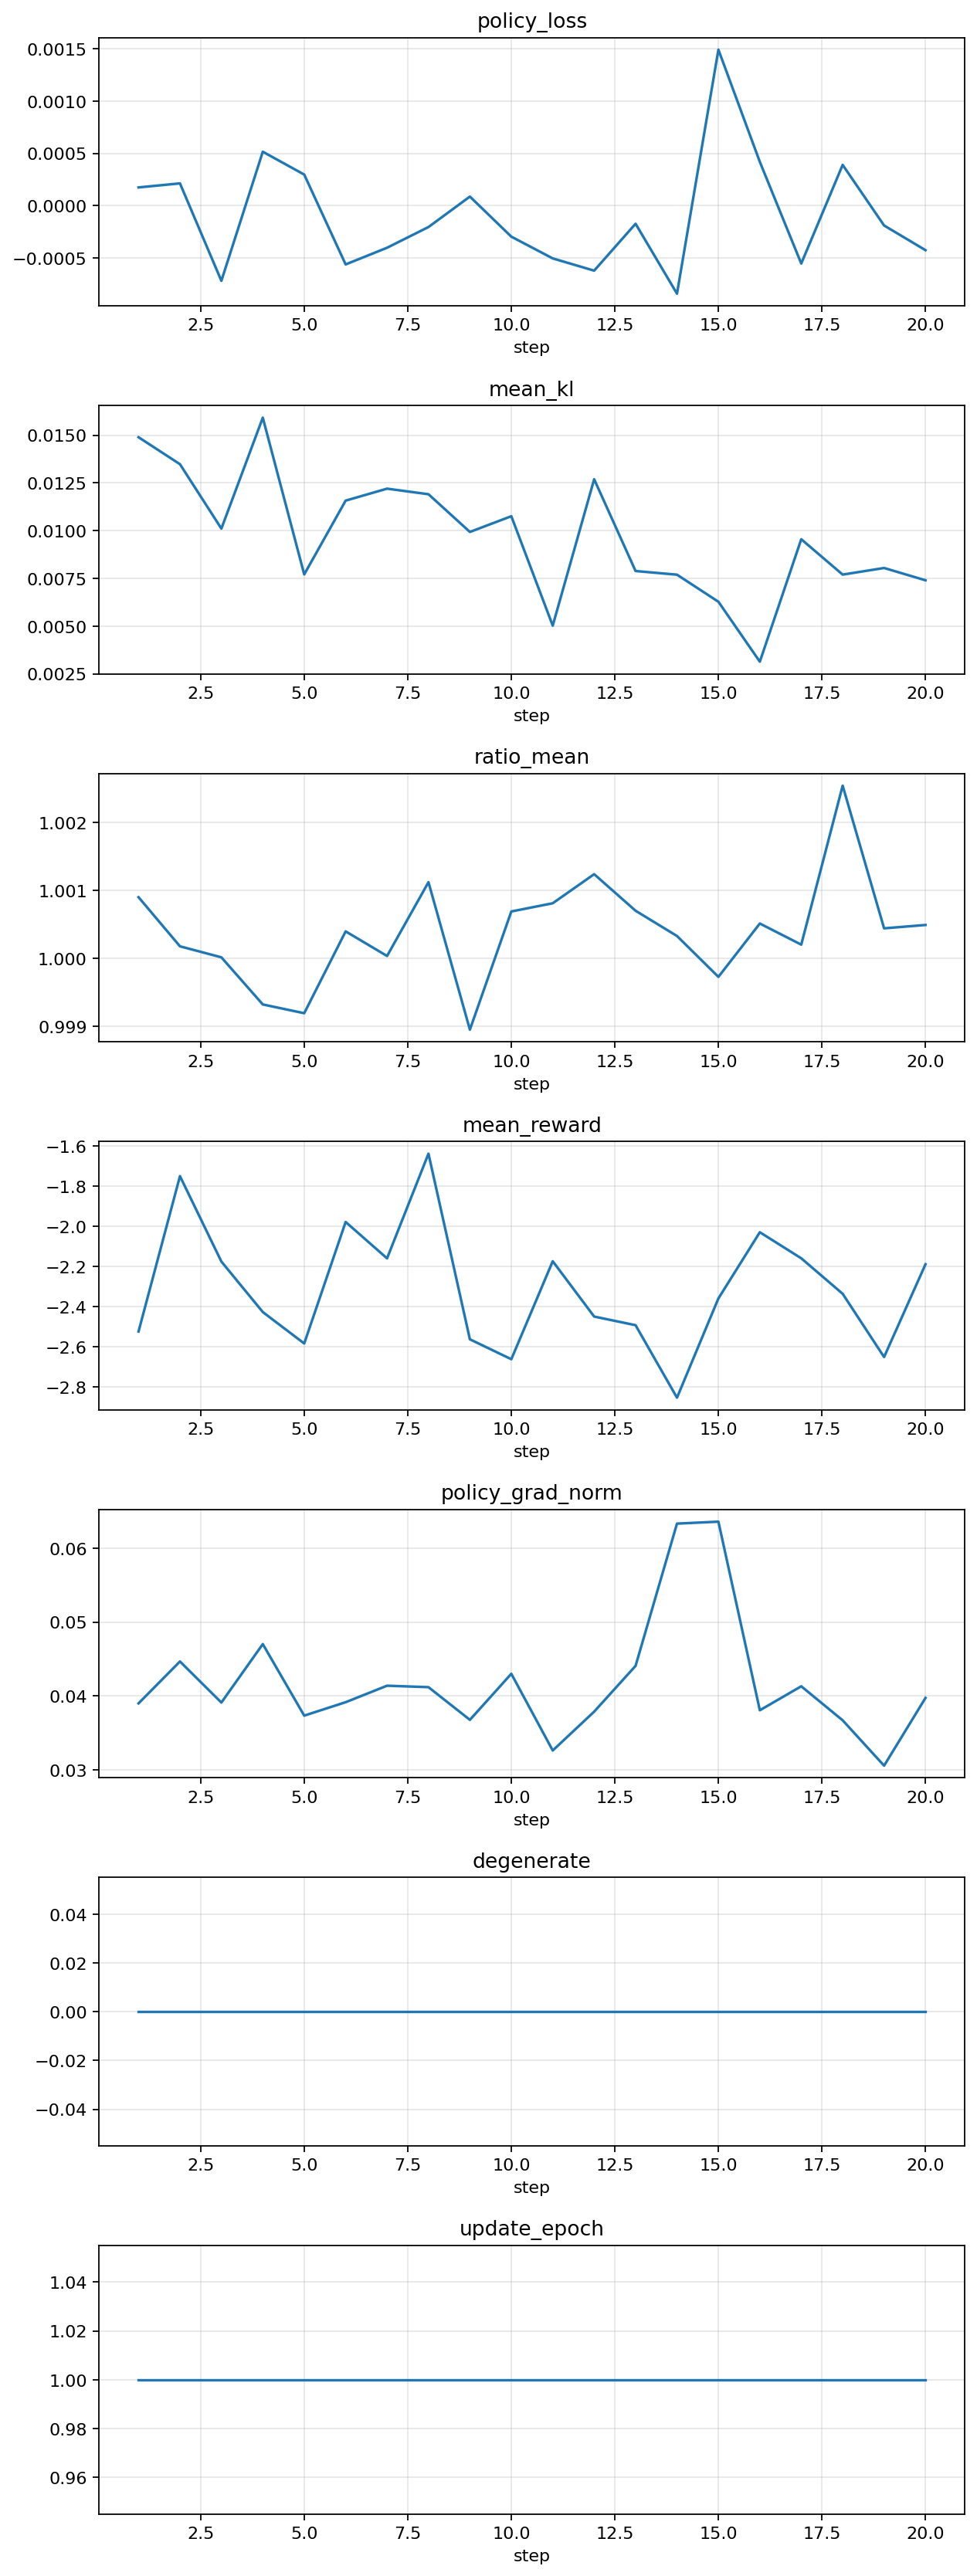

Plots for rlvr: /content/ai623_alignment_repo/runs/rlvr_20260403_114512/metrics.png


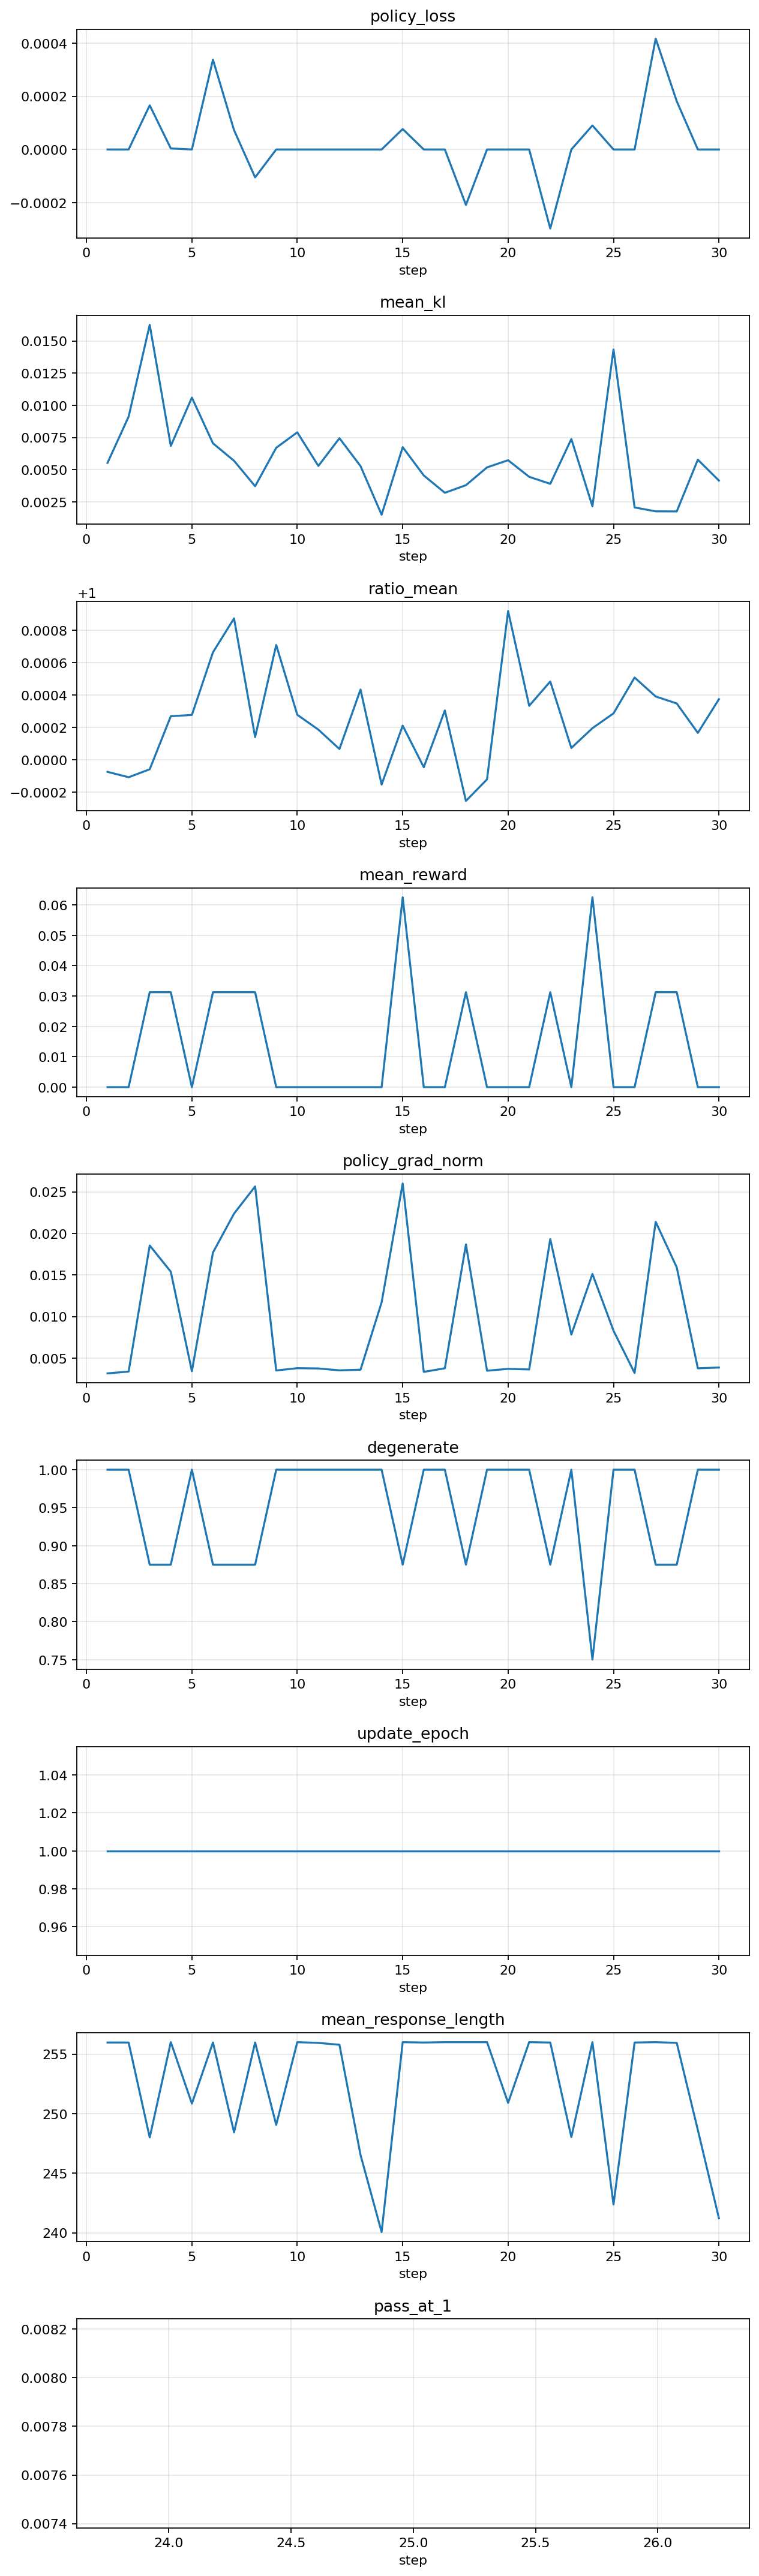

['/content/ai623_alignment_repo/runs/sft_20260403_112841/metrics.png',
 '/content/ai623_alignment_repo/runs/rm_20260403_112951/metrics.png',
 '/content/ai623_alignment_repo/runs/ppo_20260403_113723/metrics.png',
 '/content/ai623_alignment_repo/runs/grpo_20260403_114123/metrics.png',
 '/content/ai623_alignment_repo/runs/rlvr_20260403_114512/metrics.png']

In [17]:
artifacts = globals().get("artifacts", {})
plot_paths = []
for name, meta in artifacts.items():
    run_dir = Path(meta["run_dir"])
    metrics_path = run_dir / "metrics.jsonl"
    if metrics_path.exists():
        plot_path = run_dir / "metrics.png"
        plot_metric_curves(metrics_path, plot_path)
        plot_paths.append(str(plot_path))
        print(f"Plots for {name}: {plot_path}")
        display(Image(filename=str(plot_path)))
plot_paths


## Sample Generations Table

In [18]:
eval_outputs = globals().get("eval_outputs", {})
comparison_outputs = globals().get("comparison_outputs", {})
for name, payload in eval_outputs.items():
    print(f"Samples for {name}")
    display(pd.DataFrame(payload["result"]["sample_rows"]))
if comparison_outputs.get("sample_rows"):
    print("Comparison sample table")
    display(pd.DataFrame(comparison_outputs["sample_rows"]))


## Focused Ablation

Run exactly one ablation from the current runtime config and SFT checkpoint.


In [25]:
ablation_outputs = {}
if RUN_ABLATION:
    if not config["models"].get("sft_checkpoint"):
        raise ValueError("Run or set an SFT checkpoint before running ablations.")
    runtime_config_path = write_runtime_config(config, repo_root / "runs" / "notebook_runtime_config.yaml")
    cmd = ["python", "run_ablations.py", "--config", str(runtime_config_path), "--ablation", ABLATION_NAME]
    if ABLATION_NAME in {"kl_sweep", "clip_sweep"}:
        cmd += ["--method", ABLATION_METHOD]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    ablation_dirs = sorted((repo_root / "runs").glob(f"ablation_{ABLATION_NAME}_*"), key=lambda p: p.stat().st_mtime)
    if not ablation_dirs:
        raise FileNotFoundError(f"No ablation output found for {ABLATION_NAME}")
    latest_ablation_dir = ablation_dirs[-1]
    ablation_csv = latest_ablation_dir / "ablation_results.csv"
    ablation_df = pd.read_csv(ablation_csv)
    display(ablation_df)
    ablation_outputs = {
        "run_dir": str(latest_ablation_dir),
        "csv": str(ablation_csv),
        "records": ablation_df.to_dict(orient="records"),
    }
else:
    print("Skipping ablation.")

pprint(cleanup_notebook_memory())


Running: python run_ablations.py --config /content/ai623_alignment_repo/runs/notebook_runtime_config.yaml --ablation k_sweep


CalledProcessError: Command '['python', 'run_ablations.py', '--config', '/content/ai623_alignment_repo/runs/notebook_runtime_config.yaml', '--ablation', 'k_sweep']' returned non-zero exit status 2.

## Save Outputs / Checkpoints / Metrics

In [ ]:
artifacts = globals().get("artifacts", {})
eval_outputs = globals().get("eval_outputs", {})
comparison_outputs = globals().get("comparison_outputs", {})
ablation_outputs = globals().get("ablation_outputs", {})
plot_paths = globals().get("plot_paths", [])
summary = {
    "repo_root": str(repo_root),
    "artifacts": artifacts,
    "eval_outputs": eval_outputs,
    "comparison_outputs": comparison_outputs,
    "ablation_outputs": ablation_outputs,
    "plots": plot_paths,
}
summary_path = repo_root / "runs" / "notebook_summary.json"
ensure_dir(summary_path.parent)
save_json(summary_path, summary)
print(summary_path)


## Zip Scripts Helper

In [ ]:
!python tools/make_scripts_zip.py
print((repo_root / 'scripts.zip').exists(), repo_root / 'scripts.zip')

## Final Summary

In [ ]:
artifacts = globals().get("artifacts", {})
eval_outputs = globals().get("eval_outputs", {})
comparison_outputs = globals().get("comparison_outputs", {})
ablation_outputs = globals().get("ablation_outputs", {})
print('Completed notebook run.')
print('Artifacts:')
pprint(artifacts)
print('Evaluation outputs:')
pprint(eval_outputs)
print('Comparison outputs:')
pprint(comparison_outputs)
print('Ablation outputs:')
pprint(ablation_outputs)
print('scripts.zip exists:', (repo_root / 'scripts.zip').exists())
